In [ ]:
import numpy as np
import pandas as pd

In [ ]:
from sklearn import datasets
from sklearn.model_selection import train_test_split


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [ ]:
california=datasets.fetch_california_housing()
x=california.data
y=california.target

In [ ]:
california

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

In [ ]:
print(x)

[[   8.3252       41.            6.98412698 ...    2.55555556
    37.88       -122.23      ]
 [   8.3014       21.            6.23813708 ...    2.10984183
    37.86       -122.22      ]
 [   7.2574       52.            8.28813559 ...    2.80225989
    37.85       -122.24      ]
 ...
 [   1.7          17.            5.20554273 ...    2.3256351
    39.43       -121.22      ]
 [   1.8672       18.            5.32951289 ...    2.12320917
    39.43       -121.32      ]
 [   2.3886       16.            5.25471698 ...    2.61698113
    39.37       -121.24      ]]


In [ ]:
print(y)

[4.526 3.585 3.521 ... 0.923 0.847 0.894]


In [ ]:
# convert into pandas dataframe.

In [ ]:
df = pd.DataFrame(california.data, columns=california.feature_names)


In [ ]:
df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [ ]:
df.shape


(20640, 8)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,random_state=11)

In [ ]:
print(x_train.shape)
print(x_test.shape)

(16512, 8)
(4128, 8)


In [ ]:
from sklearn.linear_model import LinearRegression

# create the model
model = LinearRegression()

# train (fit) the model
model.fit(x_train, y_train)


LinearRegression()

In [ ]:
# predicted values

In [ ]:
y_pred = model.predict(x_test)


In [ ]:
y_pred2 = model.predict(x_train)

In [ ]:
print(y_pred)

[1.24721229 2.34670464 2.03549825 ... 1.49485254 3.0196528  2.02082044]


In [ ]:
print(y_pred2)

[0.68985062 2.91210697 2.13868692 ... 1.82562357 2.32478817 1.96367541]


In [ ]:
#    Finding MSE

In [ ]:
mse = mean_squared_error(y_test, y_pred)

In [ ]:
print(mse)

0.5304460892018628


In [ ]:
# Finding R2 score

In [ ]:
r2=r2_score(y_test,y_pred)

In [ ]:
print(r2)

0.605787292569561


In [ ]:
# graph between y_pridected and y_train

In [ ]:
import matplotlib.pyplot as plt

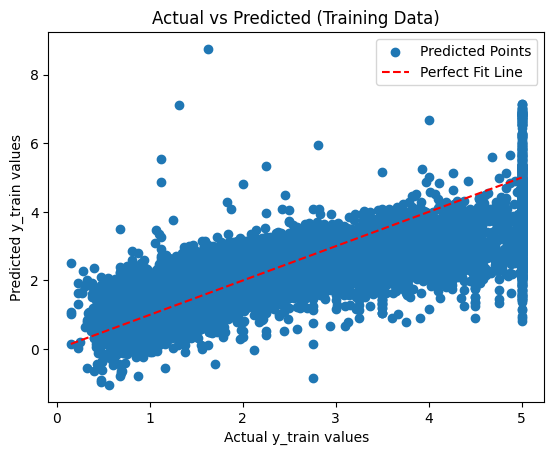

In [ ]:
plt.scatter(y_train, y_pred2, label="Predicted Points")


x_line = np.linspace(min(y_train), max(y_train), 100)
plt.plot(x_line, x_line, linestyle="--", color="red", label="Perfect Fit Line")


plt.xlabel("Actual y_train values")
plt.ylabel("Predicted y_train values")
plt.title("Actual vs Predicted (Training Data)")
plt.legend()
plt.show()


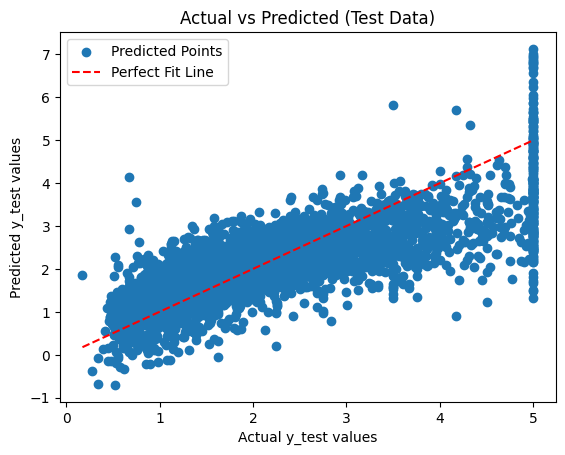

In [ ]:
plt.scatter(y_test, y_pred, label="Predicted Points")
x_line = np.linspace(min(y_test), max(y_test), 100)
plt.plot(x_line, x_line, linestyle="--", color="red", label="Perfect Fit Line")


plt.xlabel("Actual y_test values")
plt.ylabel("Predicted y_test values")
plt.title("Actual vs Predicted (Test Data)")
plt.legend()
plt.show()


# Gradient Decent Method

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [ ]:

X_train_gd = np.c_[np.ones((x_train.shape[0], 1)), x_train]
X_test_gd = np.c_[np.ones((x_test.shape[0], 1)), x_test]

In [ ]:
m, n = X_train_gd.shape

theta = np.zeros(n)
learning_rate = 0.001
iterations = 1000

In [ ]:


for i in range(iterations):

    predictions = X_train_gd.dot(theta)

    errors = predictions - y_train

    gradients = (2/m) * X_train_gd.T.dot(errors)

    theta = theta - learning_rate * gradients

In [ ]:
y_train_pred_gd = X_train_gd.dot(theta)
y_test_pred_gd = X_test_gd.dot(theta)

In [ ]:
mse_gd = mean_squared_error(y_test, y_test_pred_gd)
r2_gd = r2_score(y_test, y_test_pred_gd)

print("Gradient Descent MSE:", mse_gd)
print("Gradient Descent R2:", r2_gd)

Gradient Descent MSE: 0.6075440158952382
Gradient Descent R2: 0.5484902683520765


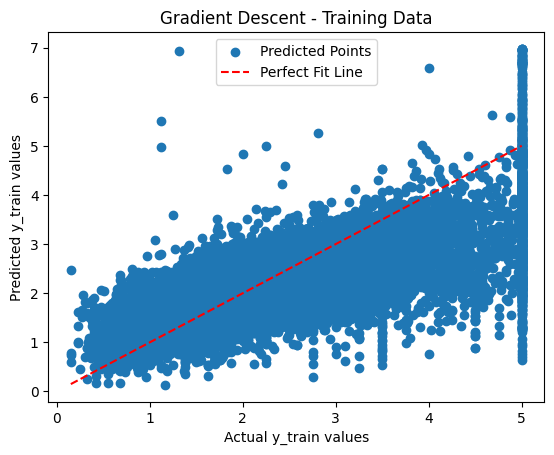

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Training plot
plt.scatter(y_train, y_train_pred_gd, label="Predicted Points")

x_line = np.linspace(min(y_train), max(y_train), 100)
plt.plot(x_line, x_line, linestyle="--", color="red", label="Perfect Fit Line")

plt.xlabel("Actual y_train values")
plt.ylabel("Predicted y_train values")
plt.title("Gradient Descent - Training Data")
plt.legend()
plt.show()

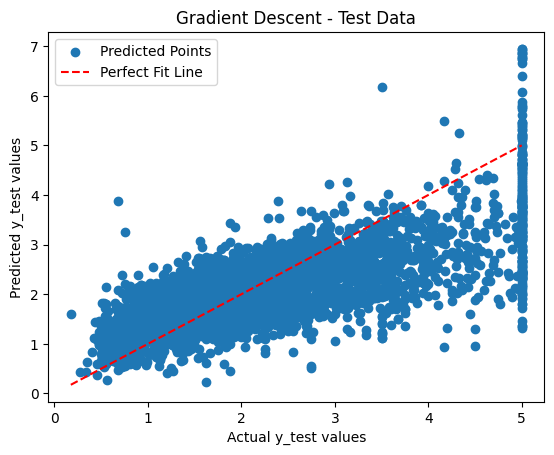

In [ ]:
# Test plot
plt.scatter(y_test, y_test_pred_gd, label="Predicted Points")

x_line = np.linspace(min(y_test), max(y_test), 100)
plt.plot(x_line, x_line, linestyle="--", color="red", label="Perfect Fit Line")

plt.xlabel("Actual y_test values")
plt.ylabel("Predicted y_test values")
plt.title("Gradient Descent - Test Data")
plt.legend()
plt.show()